In [6]:
#Check geo-time uniqueness
# Check whether each geo-time combination is unique
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
DATA_PATH = "/Users/naniyalagala003gmail.com/Downloads/geo_all_channels.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
duplicate_geo_time = df.duplicated(
    subset=["geo", "time"]
).sum()

print("Duplicate geo-time combinations:", duplicate_geo_time)

Dataset loaded successfully.
Rows: 6,240
Columns: 20
Duplicate geo-time combinations: 0


In [7]:
#Verify 156 weeks for every geography
geo_time_counts = (
    df.groupby("geo")["time"]
      .nunique()
      .sort_values()
)

print(geo_time_counts)

geo
Geo0     156
Geo29    156
Geo3     156
Geo30    156
Geo31    156
Geo32    156
Geo33    156
Geo34    156
Geo28    156
Geo35    156
Geo37    156
Geo38    156
Geo39    156
Geo4     156
Geo5     156
Geo6     156
Geo7     156
Geo36    156
Geo27    156
Geo26    156
Geo25    156
Geo1     156
Geo10    156
Geo11    156
Geo12    156
Geo13    156
Geo14    156
Geo15    156
Geo16    156
Geo17    156
Geo18    156
Geo19    156
Geo2     156
Geo20    156
Geo21    156
Geo22    156
Geo23    156
Geo24    156
Geo8     156
Geo9     156
Name: time, dtype: int64


In [8]:
print(
    "Minimum weeks per geo:",
    geo_time_counts.min()
)

print(
    "Maximum weeks per geo:",
    geo_time_counts.max()
)

Minimum weeks per geo: 156
Maximum weeks per geo: 156


In [9]:
#Check time intervals
# Check time intervals
# Check time intervals
time_points = pd.to_datetime(df["time"]).drop_duplicates().sort_values()

time_differences = (
    time_points.diff()
    .dropna()
    .dt.days
)

print(time_differences.value_counts())

time
7    155
Name: count, dtype: int64


In [10]:
print("Number of unique weeks:", len(time_points))

Number of unique weeks: 156


In [11]:
# Option 1: Explicitly define the spend columns
spend_cols = ["spend_channel_1", "spend_channel_2", "spend_channel_3"]  # Replace with your actual column names

# Option 2: Automatically select columns with 'spend' in their name
spend_cols = [col for col in df.columns if "spend" in col.lower()]

# Then run your summary code:
zero_spend_summary = pd.DataFrame({
    "zero_count": (df[spend_cols] == 0).sum(),
    "zero_percent": (df[spend_cols] == 0).mean() * 100
})
zero_spend_summary

,zero_count,zero_percent
Channel0_spend,755,12.099359
Channel1_spend,1742,27.916667
Channel2_spend,4010,64.262821
Channel3_spend,169,2.708333
Channel4_spend,820,13.141026


In [12]:
# Option 1: Explicitly define impression columns
impression_cols = ["Channel0_impression", "Channel1_impression", "Channel2_impression", "Channel3_impression", "Channel4_impression"]

# Option 2: Automatically select columns with 'impression' or 'imp' in their name
impression_cols = [col for col in df.columns if "impression" in col.lower()]

# Then run your summary code:
zero_impression_summary = pd.DataFrame({
    "zero_count": (df[impression_cols] == 0).sum(),
    "zero_percent": (df[impression_cols] == 0).mean() * 100
})
zero_impression_summary

,zero_count,zero_percent
Channel0_impression,755,12.099359
Channel1_impression,1742,27.916667
Channel2_impression,4010,64.262821
Channel3_impression,169,2.708333
Channel4_impression,820,13.141026
Organic_channel0_impression,2075,33.253205


In [13]:
comparison = pd.DataFrame({
    "zero_spend_percent": 
        (df[spend_cols] == 0).mean() * 100,
    
    "zero_impression_percent":
        (df[impression_cols] == 0).mean() * 100
})

comparison

,zero_spend_percent,zero_impression_percent
Channel0_impression,NaN,12.099359
Channel0_spend,12.099359,NaN
Channel1_impression,NaN,27.916667
Channel1_spend,27.916667,NaN
Channel2_impression,NaN,64.262821
Channel2_spend,64.262821,NaN
Channel3_impression,NaN,2.708333
Channel3_spend,2.708333,NaN
Channel4_impression,NaN,13.141026
Channel4_spend,13.141026,NaN


In [14]:
#Check whether spend and impressions are logically related

for i in range(5):
    
    spend = f"Channel{i}_spend"
    impression = f"Channel{i}_impression"
    
    corr = df[[spend, impression]].corr().iloc[0, 1]
    
    print(
        f"Channel {i}: "
        f"Spend-Impression correlation = {corr:.4f}"
    )

Channel 0: Spend-Impression correlation = 1.0000
Channel 1: Spend-Impression correlation = 1.0000
Channel 2: Spend-Impression correlation = 1.0000
Channel 3: Spend-Impression correlation = 1.0000
Channel 4: Spend-Impression correlation = 1.0000


In [15]:
# Filter to only include columns that exist in the DataFrame
cols_to_check = [col for col in spend_cols + impression_cols + ["conversions", "revenue"] if col in df.columns]

for col in cols_to_check:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n_outliers} potential outliers")

Channel0_spend: 164 potential outliers
Channel1_spend: 215 potential outliers
Channel2_spend: 941 potential outliers
Channel3_spend: 108 potential outliers
Channel4_spend: 143 potential outliers
Channel0_impression: 164 potential outliers
Channel1_impression: 215 potential outliers
Channel2_impression: 941 potential outliers
Channel3_impression: 108 potential outliers
Channel4_impression: 143 potential outliers
Organic_channel0_impression: 305 potential outliers
conversions: 56 potential outliers


In [16]:
df_clean = df.copy()

df_clean = df_clean.sort_values(
    ["geo", "time"]
).reset_index(drop=True)
print(df_clean.shape)
print(df_clean.isna().sum().sum())

(6240, 20)
0


In [17]:
# Convert time column to datetime format first
df_clean["time"] = pd.to_datetime(df_clean["time"])

# Extract date features
df_clean["year"] = df_clean["time"].dt.year
df_clean["month"] = df_clean["time"].dt.month
df_clean["quarter"] = df_clean["time"].dt.quarter
df_clean["week"] = df_clean["time"].dt.isocalendar().week.astype(int)

In [18]:
df_clean[
    ["time", "year", "month", "quarter", "week"]
].head(10)


,time,year,month,quarter,week
0,2021-01-25,2021,1,1,4
1,2021-02-01,2021,2,1,5
2,2021-02-08,2021,2,1,6
3,2021-02-15,2021,2,1,7
4,2021-02-22,2021,2,1,8
5,2021-03-01,2021,3,1,9
6,2021-03-08,2021,3,1,10
7,2021-03-15,2021,3,1,11
8,2021-03-22,2021,3,1,12
9,2021-03-29,2021,3,1,13


In [19]:
# Create total marketing spend column
df_clean["total_marketing_spend"] = df_clean[spend_cols].sum(axis=1)

# Describe only columns that actually exist in df_clean
target_cols = ["total_marketing_spend", "conversions", "revenue"]
existing_cols = [col for col in target_cols if col in df_clean.columns]

df_clean[existing_cols].describe()

,total_marketing_spend,conversions
count,6240.000000,6.240000e+03
mean,35175.064479,1.056582e+07
std,25381.766932,6.079411e+06
min,0.000000,4.840312e+05
25%,15919.771275,5.718118e+06
50%,29109.431750,9.709094e+06
75%,48775.248575,1.439186e+07
max,184340.343000,3.671269e+07


In [20]:
#Create channel spend shares
for col in spend_cols:
    
    channel_name = col.replace("_spend", "")
    
    df_clean[f"{channel_name}_share"] = (
        df_clean[col] /
        df_clean["total_marketing_spend"]
    )

In [21]:
(df_clean["total_marketing_spend"] == 0).sum()

np.int64(19)

In [22]:
# 03_EDA 

In [23]:
# Question 1 How does conversion change over time?

# Question 2 - How does marketing spending change over time?

# Question 3 - How different are the 40 geographies?

# Question 4 - How are marketing channels related to the outcome?

In [28]:
print(df_clean.columns)

Index(['Unnamed: 0', 'geo', 'time', 'Channel0_impression',
       'Channel1_impression', 'Channel2_impression', 'Channel3_impression',
       'Channel4_impression', 'competitor_sales_control',
       'sentiment_score_control', 'Channel0_spend', 'Channel1_spend',
       'Channel2_spend', 'Channel3_spend', 'Channel4_spend',
       'Organic_channel0_impression', 'Promo', 'conversions',
       'revenue_per_conversion', 'population', 'year', 'month', 'quarter',
       'week', 'total_marketing_spend', 'Channel0_share', 'Channel1_share',
       'Channel2_share', 'Channel3_share', 'Channel4_share', 'revenue'],
      dtype='object')


In [27]:
# Create the total revenue column first, then calculate weekly KPIs
df_clean["revenue"] = df_clean["conversions"] * df_clean["revenue_per_conversion"]

weekly_kpi = (
    df_clean
    .groupby("time")
    .agg(
        conversions=("conversions", "sum"),
        revenue=("revenue", "sum"),
        population=("population", "sum")
    )
)

weekly_kpi.head()

,conversions,revenue,population
time,,,
2021-01-25,386300926.3,7.731975e+06,21696753.31
2021-02-01,355303931.3,7.104532e+06,21696753.31
2021-02-08,438308889.8,8.762589e+06,21696753.31
2021-02-15,418612413.7,8.363356e+06,21696753.31
2021-02-22,355785298.0,7.109799e+06,21696753.31


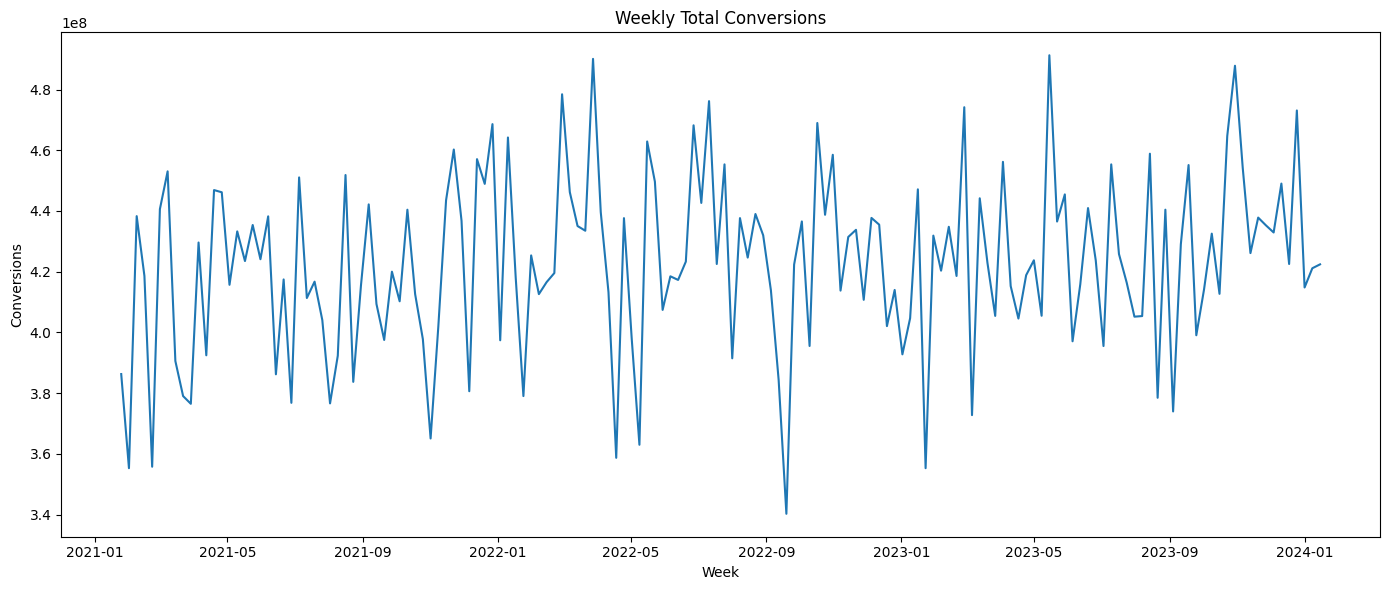

In [31]:
plt.figure(figsize=(14, 6))

plt.plot(
    weekly_kpi.index,
    weekly_kpi["conversions"]
)

plt.title("Weekly Total Conversions")
plt.xlabel("Week")
plt.ylabel("Conversions")

plt.tight_layout()
plt.show()

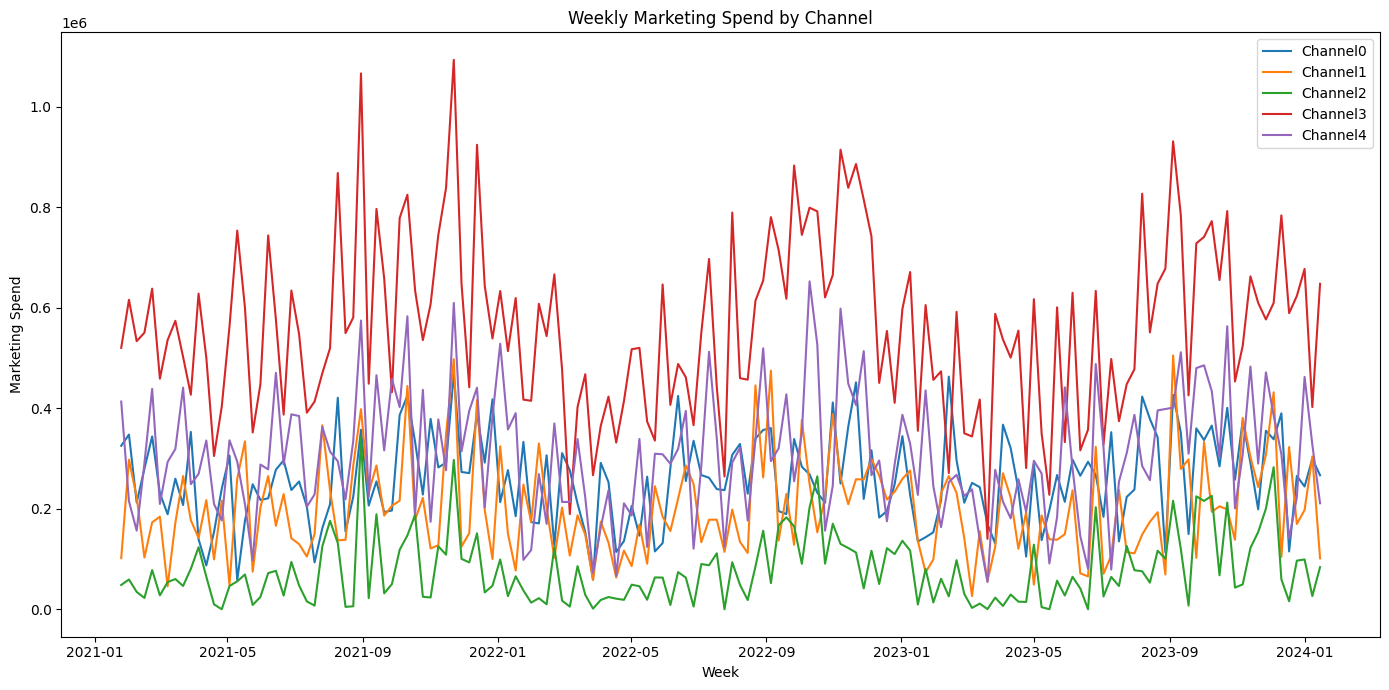

In [32]:
weekly_spend = (
    df_clean
    .groupby("time")[spend_cols]
    .sum()
)

plt.figure(figsize=(14, 7))

for col in spend_cols:
    plt.plot(
        weekly_spend.index,
        weekly_spend[col],
        label=col.replace("_spend", "")
    )

plt.title("Weekly Marketing Spend by Channel")
plt.xlabel("Week")
plt.ylabel("Marketing Spend")
plt.legend()

plt.tight_layout()
plt.show()

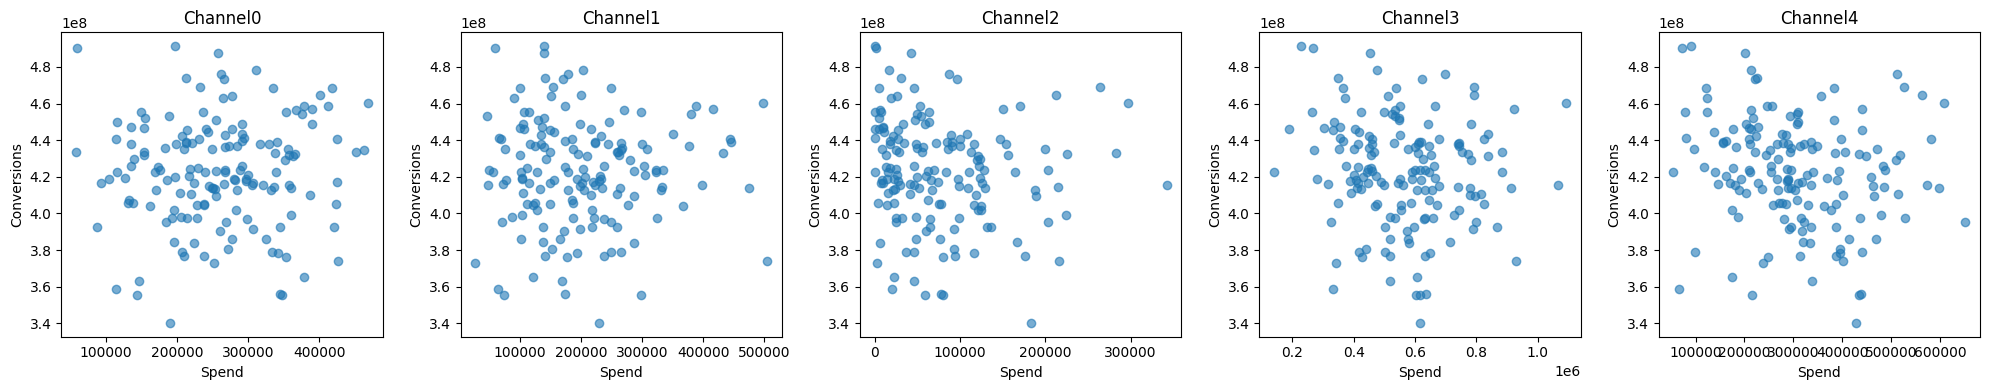

In [35]:
weekly_analysis = weekly_spend.copy()

weekly_analysis["conversions"] = (
    df_clean
    .groupby("time")["conversions"]
    .sum()
)
fig, axes = plt.subplots(
    1, 5,
    figsize=(20, 4)
)

for i, col in enumerate(spend_cols):
    
    axes[i].scatter(
        weekly_analysis[col],
        weekly_analysis["conversions"],
        alpha=0.6
    )
    
    axes[i].set_title(
        col.replace("_spend", "")
    )
    
    axes[i].set_xlabel("Spend")
    axes[i].set_ylabel("Conversions")

plt.tight_layout()
plt.show()

In [36]:
# Geography Analysis

In [37]:
geo_analysis = (
    df_clean
    .groupby("geo")
    .agg(
        total_conversions=("conversions", "sum"),
        total_revenue=("revenue", "sum"),
        avg_population=("population", "mean"),
        total_spend=("total_marketing_spend", "sum")
    )
)

geo_analysis["conversions_per_population"] = (
    geo_analysis["total_conversions"] /
    geo_analysis["avg_population"]
)

geo_analysis.sort_values(
    "total_conversions",
    ascending=False
).head(10)

,total_conversions,total_revenue,avg_population,total_spend,conversions_per_population
geo,,,,,
Geo36,3.290565e+09,6.581648e+07,969886.50,9.761024e+06,3392.731899
Geo39,3.222847e+09,6.448245e+07,798939.10,7.801775e+06,4033.907885
Geo10,3.093954e+09,6.191079e+07,994048.94,9.680096e+06,3112.476560
Geo23,2.836450e+09,5.673184e+07,981570.90,9.937170e+06,2889.704471
Geo31,2.684670e+09,5.367754e+07,873369.70,8.667995e+06,3073.921343
Geo7,2.578130e+09,5.153221e+07,733989.56,7.718127e+06,3512.488915
Geo2,2.468820e+09,4.937024e+07,892369.50,9.432803e+06,2766.589608
Geo25,2.437115e+09,4.872741e+07,779181.90,7.990459e+06,3127.786991
Geo17,2.201843e+09,4.408524e+07,777539.94,8.022049e+06,2831.806680


In [38]:
# Geography Visualization

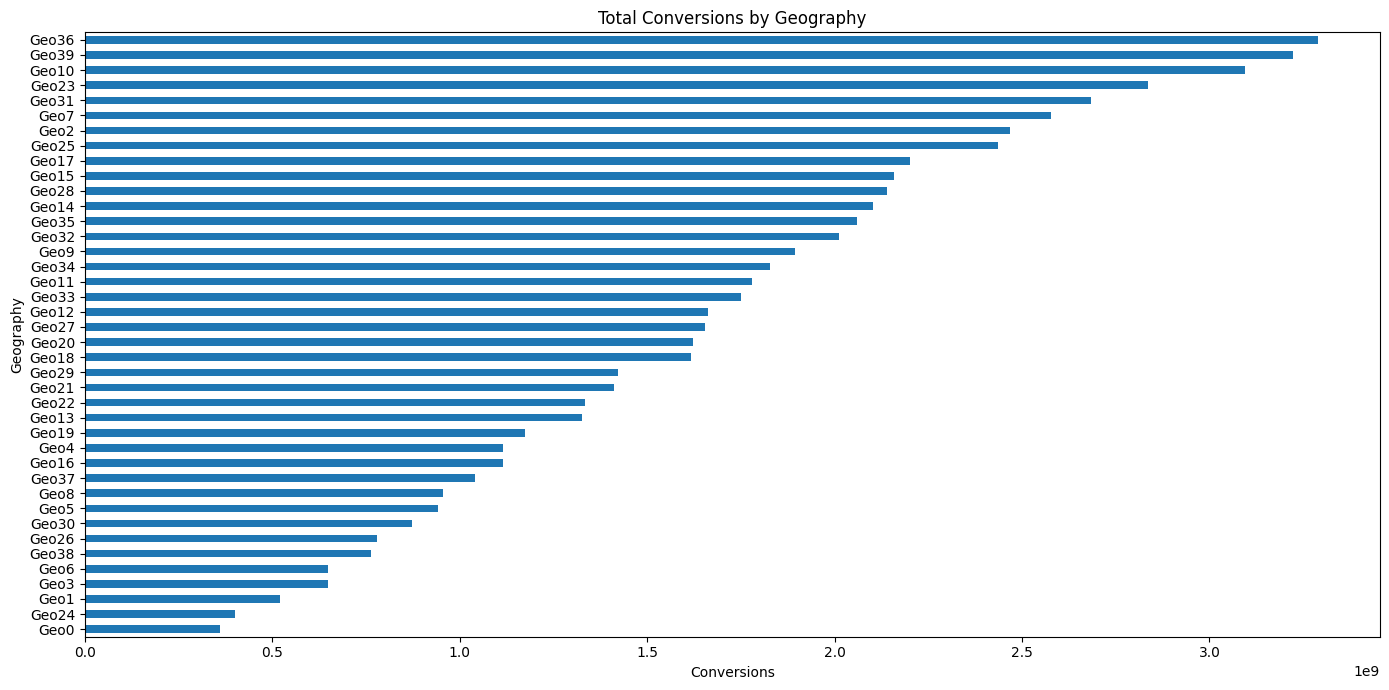

In [39]:
plt.figure(figsize=(14, 7))

geo_analysis["total_conversions"].sort_values().plot(
    kind="barh"
)

plt.title("Total Conversions by Geography")
plt.xlabel("Conversions")
plt.ylabel("Geography")

plt.tight_layout()
plt.show()

In [47]:
print(time_differences.value_counts())
zero_spend_summary
zero_impression_summary
comparison
(df_clean["total_marketing_spend"] == 0).sum()

time
7    155
Name: count, dtype: int64


np.int64(19)

In [48]:
# Select channels and target columns
spend_cols = [c for c in df_clean.columns if "spend" in c]
impression_cols = [c for c in df_clean.columns if "impression" in c]
cols_to_check = spend_cols + impression_cols + ["conversions", "revenue"]

# IQR Outlier Detection
for col in cols_to_check:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_outliers = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f"{col}: {n_outliers} potential outliers")

Channel0_spend: 164 potential outliers
Channel1_spend: 215 potential outliers
Channel2_spend: 941 potential outliers
Channel3_spend: 108 potential outliers
Channel4_spend: 143 potential outliers
total_marketing_spend: 151 potential outliers
Channel0_impression: 164 potential outliers
Channel1_impression: 215 potential outliers
Channel2_impression: 941 potential outliers
Channel3_impression: 108 potential outliers
Channel4_impression: 143 potential outliers
Organic_channel0_impression: 305 potential outliers
conversions: 56 potential outliers
revenue: 57 potential outliers


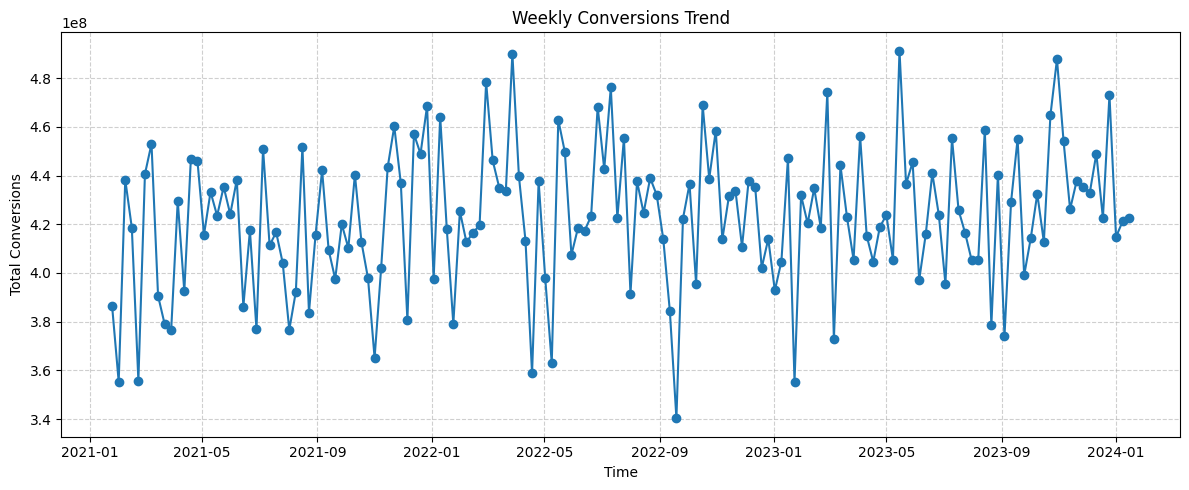

In [49]:
import matplotlib.pyplot as plt

weekly_kpi = df_clean.groupby("time").agg({"conversions": "sum"}).reset_index()

plt.figure(figsize=(12, 5))
plt.plot(weekly_kpi["time"], weekly_kpi["conversions"], marker="o", color="tab:blue")
plt.title("Weekly Conversions Trend")
plt.xlabel("Time")
plt.ylabel("Total Conversions")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

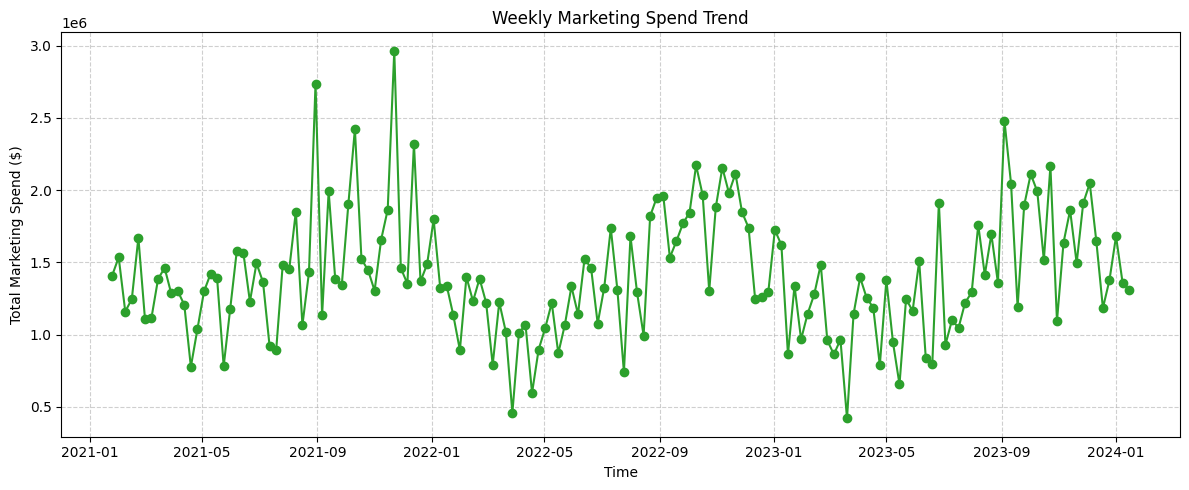

In [50]:
weekly_spend = df_clean.groupby("time").agg({"total_marketing_spend": "sum"}).reset_index()

plt.figure(figsize=(12, 5))
plt.plot(weekly_spend["time"], weekly_spend["total_marketing_spend"], marker="o", color="tab:green")
plt.title("Weekly Marketing Spend Trend")
plt.xlabel("Time")
plt.ylabel("Total Marketing Spend ($)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

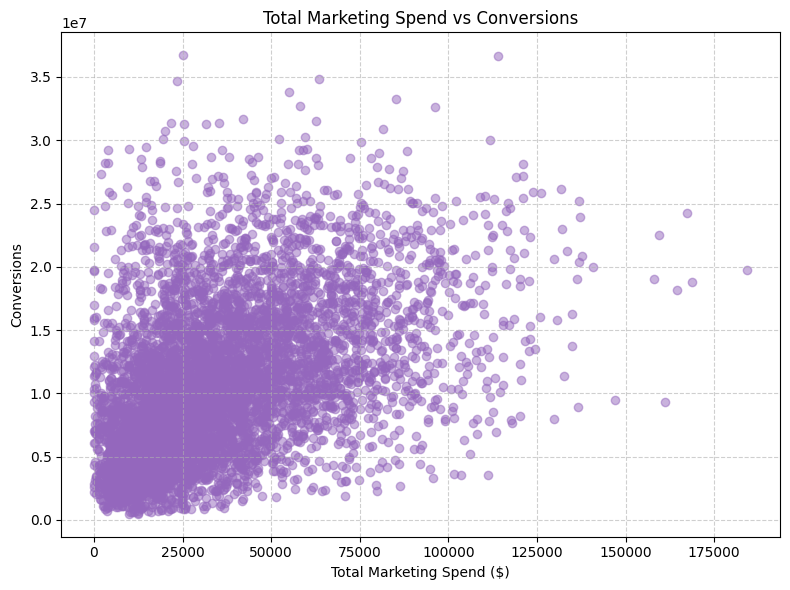

In [51]:
plt.figure(figsize=(8, 6))
plt.scatter(df_clean["total_marketing_spend"], df_clean["conversions"], alpha=0.5, color="tab:purple")
plt.title("Total Marketing Spend vs Conversions")
plt.xlabel("Total Marketing Spend ($)")
plt.ylabel("Conversions")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [52]:
# spend v/s Impression Relationship

In [53]:
for i in range(5):
    spend = f"Channel{i}_spend"
    impression = f"Channel{i}_impression"

    corr = df_clean[[spend, impression]].corr().iloc[0, 1]

    print(
        f"Channel {i}: "
        f"Spend-Impression correlation = {corr:.4f}"
    )

Channel 0: Spend-Impression correlation = 1.0000
Channel 1: Spend-Impression correlation = 1.0000
Channel 2: Spend-Impression correlation = 1.0000
Channel 3: Spend-Impression correlation = 1.0000
Channel 4: Spend-Impression correlation = 1.0000


In [54]:
# Monthly conversion pattern 

In [55]:
monthly_conversions = (
    df_clean
    .groupby("month")["conversions"]
    .mean()
)

monthly_conversions

month
1     1.028718e+07
2     1.050654e+07
3     1.055761e+07
4     1.054026e+07
5     1.069272e+07
6     1.046615e+07
7     1.072743e+07
8     1.040737e+07
9     1.018168e+07
10    1.084179e+07
11    1.067483e+07
12    1.087952e+07
Name: conversions, dtype: float64

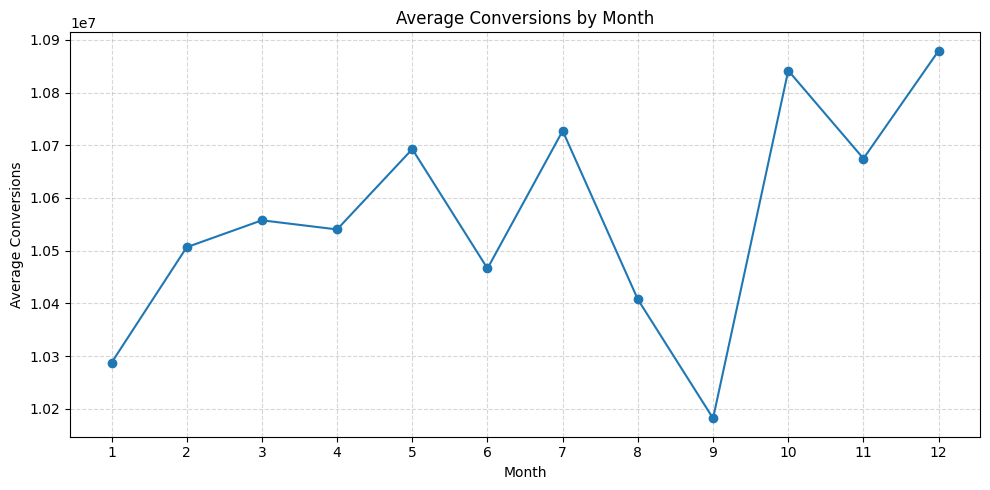

In [56]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_conversions.index,
    monthly_conversions.values,
    marker="o"
)

plt.title("Average Conversions by Month")
plt.xlabel("Month")
plt.ylabel("Average Conversions")
plt.xticks(range(1, 13))
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [57]:
quarterly_conversions = (
    df_clean
    .groupby("quarter")["conversions"]
    .mean()
)

quarterly_conversions

quarter
1    1.044482e+07
2    1.057610e+07
3    1.044461e+07
4    1.079775e+07
Name: conversions, dtype: float64

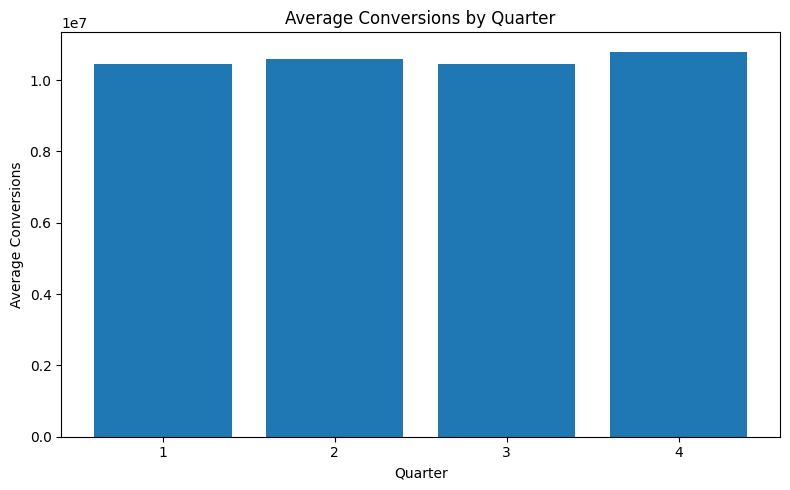

In [58]:
plt.figure(figsize=(8, 5))

plt.bar(
    quarterly_conversions.index.astype(str),
    quarterly_conversions.values
)

plt.title("Average Conversions by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Average Conversions")

plt.tight_layout()
plt.show()

In [59]:
yearly_summary = (
    df_clean
    .groupby("year")
    .agg(
        conversions=("conversions", "mean"),
        revenue=("revenue", "mean"),
        marketing_spend=("total_marketing_spend", "mean")
    )
)

yearly_summary

,conversions,revenue,marketing_spend
year,,,
2021,1.038594e+07,207750.212328,36611.807915
2022,1.064129e+07,212838.687680,34657.304378
2023,1.066442e+07,213288.295821,34277.405546
2024,1.048656e+07,209707.465749,36242.184957


In [60]:
channel_summary = pd.DataFrame({
    "Total Spend": df_clean[spend_cols].sum(),
    "Average Spend": df_clean[spend_cols].mean(),
    "Median Spend": df_clean[spend_cols].median(),
    "SD": df_clean[spend_cols].std(),
    "Zero Spend %": (df_clean[spend_cols] == 0).mean() * 100
})

channel_summary

,Total Spend,Average Spend,Median Spend,SD,Zero Spend %
Channel0_spend,4.050171e+07,6490.659147,4983.83550,6008.031135,12.099359
Channel1_spend,3.132030e+07,5019.278558,2995.07265,5983.571424,27.916667
Channel2_spend,1.207935e+07,1935.793164,0.00000,4125.531614,64.262821
Channel3_spend,8.786036e+07,14080.185617,11731.17850,10168.239254,2.708333
Channel4_spend,4.773068e+07,7649.147993,5814.69460,7123.184932,13.141026
total_marketing_spend,2.194924e+08,35175.064479,29109.43175,25381.766932,0.304487


In [61]:
channel_summary["Spend Share %"] = (
    channel_summary["Total Spend"]
    / channel_summary["Total Spend"].sum()
    * 100
)

channel_summary

,Total Spend,Average Spend,Median Spend,SD,Zero Spend %,Spend Share %
Channel0_spend,4.050171e+07,6490.659147,4983.83550,6008.031135,12.099359,9.226222
Channel1_spend,3.132030e+07,5019.278558,2995.07265,5983.571424,27.916667,7.134711
Channel2_spend,1.207935e+07,1935.793164,0.00000,4125.531614,64.262821,2.751655
Channel3_spend,8.786036e+07,14080.185617,11731.17850,10168.239254,2.708333,20.014442
Channel4_spend,4.773068e+07,7649.147993,5814.69460,7123.184932,13.141026,10.872969
total_marketing_spend,2.194924e+08,35175.064479,29109.43175,25381.766932,0.304487,50.000000


In [62]:
channel_conversion_corr = {}

for col in spend_cols:
    channel_conversion_corr[col] = (
        df_clean[[col, "conversions"]]
        .corr()
        .iloc[0, 1]
    )

channel_conversion_corr = (
    pd.Series(channel_conversion_corr)
    .sort_values(ascending=False)
)

channel_conversion_corr

total_marketing_spend    0.476661
Channel3_spend           0.468854
Channel0_spend           0.413823
Channel4_spend           0.348243
Channel1_spend           0.293146
Channel2_spend           0.147900
dtype: float64

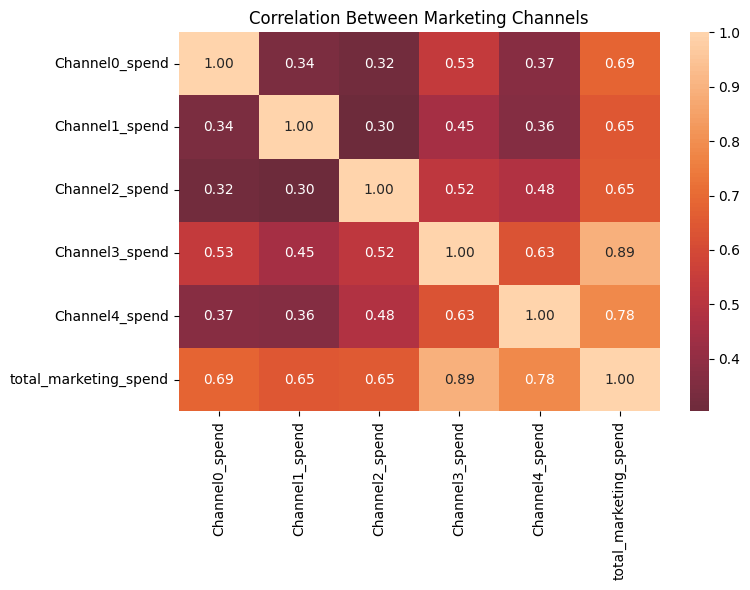

In [63]:
spend_corr = df_clean[spend_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    spend_corr,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Correlation Between Marketing Channels")

plt.tight_layout()
plt.show()


========== CHANNEL SUMMARY ==========

                Total Spend  Average Spend  Zero Spend %  Spend Share %
Channel0_spend  40501713.08        6490.66         12.10          18.45
Channel1_spend  31320298.20        5019.28         27.92          14.27
Channel2_spend  12079349.34        1935.79         64.26           5.50
Channel3_spend  87860358.25       14080.19          2.71          40.03
Channel4_spend  47730683.48        7649.15         13.14          21.75

========== SPEND vs CONVERSIONS CORRELATION ==========

Channel0_spend    0.414
Channel1_spend    0.293
Channel2_spend    0.148
Channel3_spend    0.469
Channel4_spend    0.348
dtype: float64

========== CHANNEL CORRELATION ==========

                Channel0_spend  Channel1_spend  Channel2_spend  \
Channel0_spend           1.000           0.342           0.315   
Channel1_spend           0.342           1.000           0.304   
Channel2_spend           0.315           0.304           1.000   
Channel3_spend           0.5

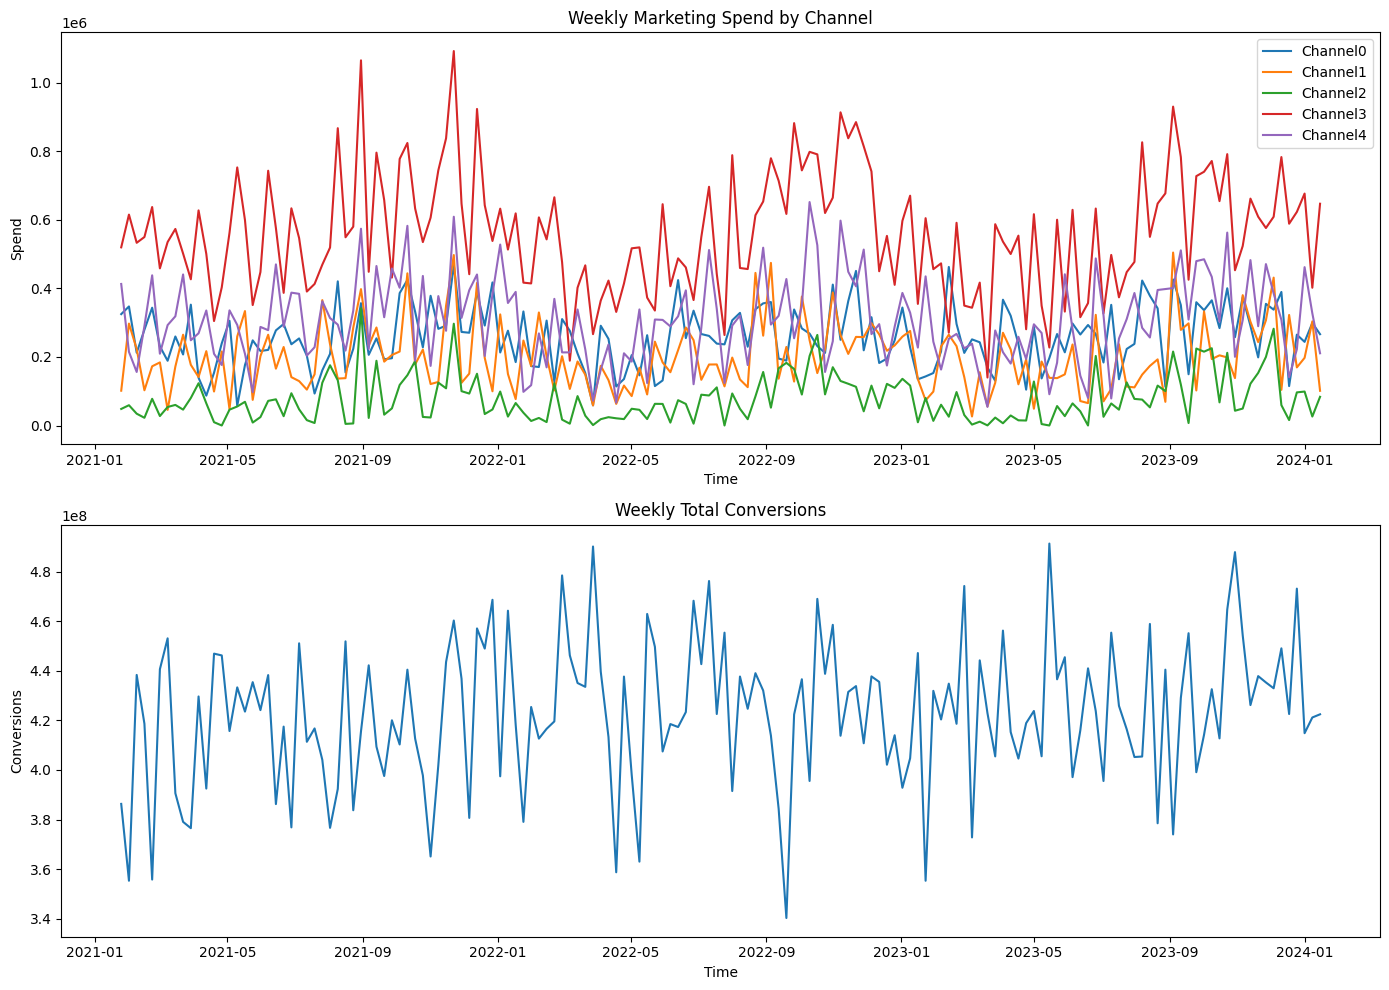

In [64]:
# ============================================
# MARKETING MIX MODELING — EDA SUMMARY
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# ---- 1. Channel summary ----

spend_cols = [
    "Channel0_spend",
    "Channel1_spend",
    "Channel2_spend",
    "Channel3_spend",
    "Channel4_spend"
]

channel_summary = pd.DataFrame({
    "Total Spend": df_clean[spend_cols].sum(),
    "Average Spend": df_clean[spend_cols].mean(),
    "Zero Spend %": (
        df_clean[spend_cols] == 0
    ).mean() * 100
})

channel_summary["Spend Share %"] = (
    channel_summary["Total Spend"]
    / channel_summary["Total Spend"].sum()
    * 100
)

print("\n========== CHANNEL SUMMARY ==========\n")
print(channel_summary.round(2))


# ---- 2. Channel vs conversions correlation ----

correlations = {}

for col in spend_cols:
    correlations[col] = (
        df_clean[[col, "conversions"]]
        .corr()
        .iloc[0, 1]
    )

correlations = pd.Series(correlations)

print("\n========== SPEND vs CONVERSIONS CORRELATION ==========\n")
print(correlations.round(3))


# ---- 3. Channel-to-channel correlation ----

print("\n========== CHANNEL CORRELATION ==========\n")

channel_corr = df_clean[spend_cols].corr()

print(channel_corr.round(3))


# ---- 4. Monthly conversion pattern ----

monthly = (
    df_clean
    .groupby("month")["conversions"]
    .mean()
)

print("\n========== MONTHLY CONVERSIONS ==========\n")
print(monthly.round(0))


# ---- 5. Yearly summary ----

yearly = (
    df_clean
    .groupby("year")
    .agg(
        conversions=("conversions", "mean"),
        revenue=("revenue", "mean"),
        marketing_spend=("total_marketing_spend", "mean")
    )
)

print("\n========== YEARLY SUMMARY ==========\n")
print(yearly.round(2))


# ---- 6. One useful visualization ----

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Marketing spend
weekly_spend = (
    df_clean
    .groupby("time")[spend_cols]
    .sum()
)

for col in spend_cols:
    axes[0].plot(
        weekly_spend.index,
        weekly_spend[col],
        label=col.replace("_spend", "")
    )

axes[0].set_title("Weekly Marketing Spend by Channel")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Spend")
axes[0].legend()


# Conversions
weekly_conversions = (
    df_clean
    .groupby("time")["conversions"]
    .sum()
)

axes[1].plot(
    weekly_conversions.index,
    weekly_conversions.values
)

axes[1].set_title("Weekly Total Conversions")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Conversions")

plt.tight_layout()
plt.show()

TIME-BASED TRAIN / TEST SPLIT
Training period: 2021-01-25 00:00:00 to 2023-06-05 00:00:00
Testing period: 2023-06-12 00:00:00 to 2024-01-15 00:00:00
Training observations: 4960
Testing observations: 1280


MODEL PERFORMANCE
Model     R2         RMSE          MAE
  OLS 0.4734 4537676.5284 3434455.1198
Ridge 0.4734 4537635.1702 3434457.0860


OLS COEFFICIENTS
                Variable   Coefficient  P_value
                   const  3.489201e+06 0.000000
          Channel0_spend  2.027501e+02 0.000000
          Channel1_spend  1.056293e+02 0.000000
          Channel2_spend  1.645862e+01 0.431505
          Channel3_spend  2.867928e+02 0.000000
          Channel4_spend  1.754799e+02 0.000000
competitor_sales_control -1.972710e+06 0.000000
 sentiment_score_control -1.669672e+06 0.000000
                   Promo -8.506280e+05 0.000000


RIDGE COEFFICIENTS
                Variable   Coefficient
          Channel0_spend  1.190009e+06
          Channel1_spend  6.228027e+05
          Channel2_spe

/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


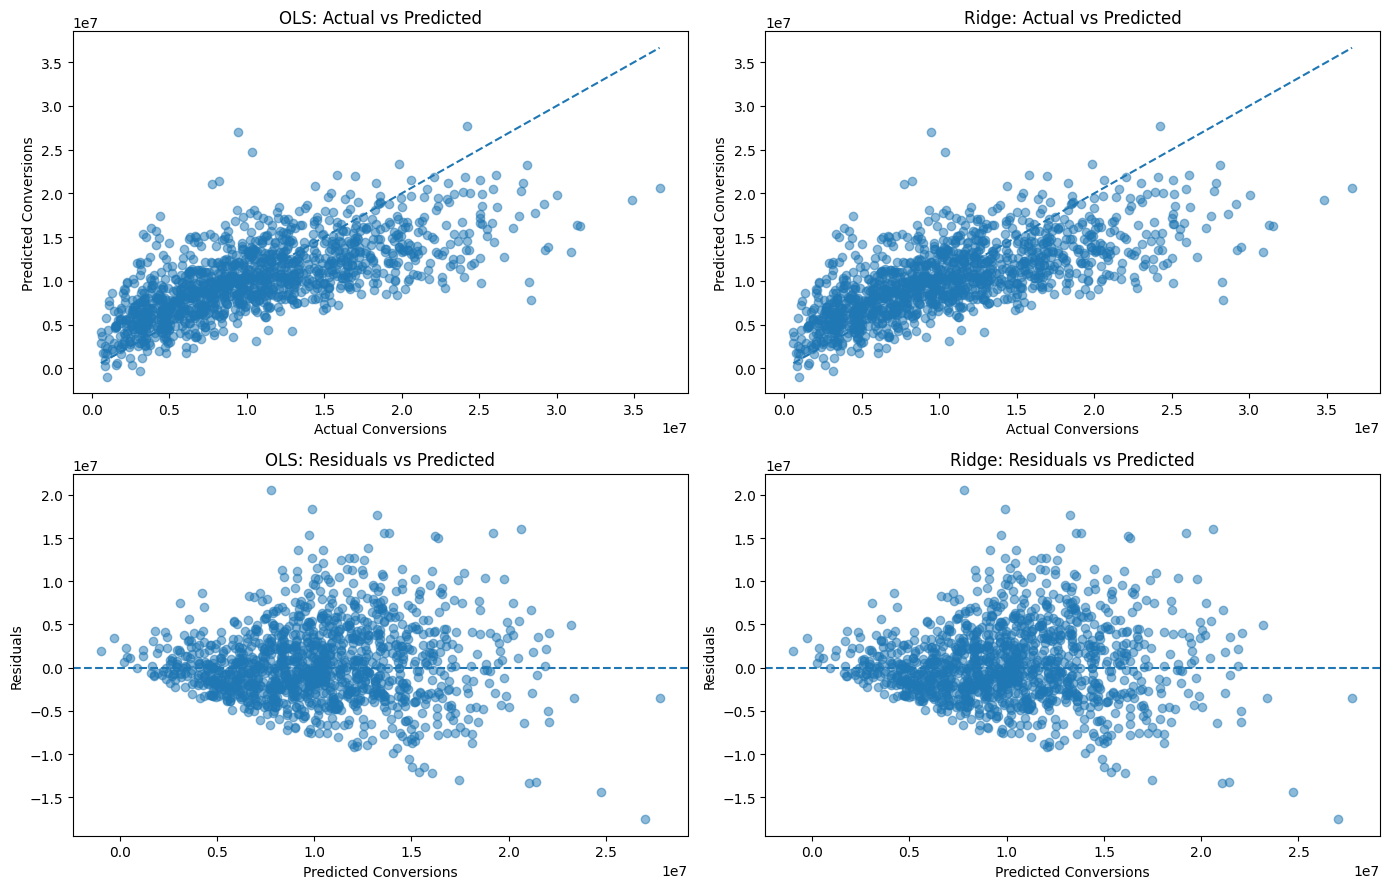


Results saved successfully.


In [65]:
# ============================================================
# BASELINE MODELS: OLS vs RIDGE
# Marketing Mix Modeling Project
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# ------------------------------------------------------------
# 1. DEFINE VARIABLES
# ------------------------------------------------------------

spend_cols = [
    "Channel0_spend",
    "Channel1_spend",
    "Channel2_spend",
    "Channel3_spend",
    "Channel4_spend"
]

control_cols = [
    "competitor_sales_control",
    "sentiment_score_control",
    "Promo"
]

target = "conversions"

features = spend_cols + control_cols


# ------------------------------------------------------------
# 2. CREATE MODEL DATA
# ------------------------------------------------------------

model_df = df_clean[
    ["time", target] + features
].copy()

model_df = model_df.sort_values("time").reset_index(drop=True)

X = model_df[features]
y = model_df[target]


# ------------------------------------------------------------
# 3. TIME-BASED TRAIN / TEST SPLIT
# ------------------------------------------------------------
# First 80% of time = training
# Last 20% of time = testing
#
# IMPORTANT:
# We split by TIME, not randomly, because this is a
# marketing time-series problem.

unique_dates = model_df["time"].sort_values().unique()

split_position = int(len(unique_dates) * 0.80)

split_date = unique_dates[split_position]

train = model_df[
    model_df["time"] < split_date
].copy()

test = model_df[
    model_df["time"] >= split_date
].copy()

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("=" * 60)
print("TIME-BASED TRAIN / TEST SPLIT")
print("=" * 60)

print("Training period:",
      train["time"].min(),
      "to",
      train["time"].max())

print("Testing period:",
      test["time"].min(),
      "to",
      test["time"].max())

print("Training observations:", len(train))
print("Testing observations:", len(test))


# ------------------------------------------------------------
# 4. MODEL 1 — OLS
# ------------------------------------------------------------

X_train_ols = sm.add_constant(X_train)
X_test_ols = sm.add_constant(
    X_test,
    has_constant="add"
)

ols_model = sm.OLS(
    y_train,
    X_train_ols
).fit()

ols_pred = ols_model.predict(
    X_test_ols
)

ols_residuals = y_test - ols_pred


# ------------------------------------------------------------
# 5. MODEL 2 — RIDGE
# ------------------------------------------------------------
# Standardization is important for Ridge because the
# penalty depends on coefficient magnitude.

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_model.fit(
    X_train,
    y_train
)

ridge_pred = ridge_model.predict(
    X_test
)

ridge_residuals = y_test - ridge_pred


# ------------------------------------------------------------
# 6. MODEL PERFORMANCE
# ------------------------------------------------------------

results = pd.DataFrame({
    "Model": ["OLS", "Ridge"],
    "R2": [
        r2_score(y_test, ols_pred),
        r2_score(y_test, ridge_pred)
    ],
    "RMSE": [
        np.sqrt(
            mean_squared_error(
                y_test,
                ols_pred
            )
        ),
        np.sqrt(
            mean_squared_error(
                y_test,
                ridge_pred
            )
        )
    ],
    "MAE": [
        mean_absolute_error(
            y_test,
            ols_pred
        ),
        mean_absolute_error(
            y_test,
            ridge_pred
        )
    ]
})

print("\n")
print("=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(
    results.round(4).to_string(index=False)
)


# ------------------------------------------------------------
# 7. OLS COEFFICIENTS
# ------------------------------------------------------------

ols_coefficients = pd.DataFrame({
    "Variable": ols_model.params.index,
    "Coefficient": ols_model.params.values,
    "P_value": ols_model.pvalues.values
})

print("\n")
print("=" * 60)
print("OLS COEFFICIENTS")
print("=" * 60)

print(
    ols_coefficients.round(6).to_string(index=False)
)


# ------------------------------------------------------------
# 8. RIDGE COEFFICIENTS
# ------------------------------------------------------------

ridge_coefficients = pd.DataFrame({
    "Variable": features,
    "Coefficient": ridge_model.named_steps[
        "ridge"
    ].coef_
})

print("\n")
print("=" * 60)
print("RIDGE COEFFICIENTS")
print("=" * 60)

print(
    ridge_coefficients.round(6).to_string(index=False)
)


# ------------------------------------------------------------
# 9. COEFFICIENT COMPARISON
# ------------------------------------------------------------

coefficient_comparison = pd.DataFrame({
    "Variable": features,
    "OLS": ols_model.params[features].values,
    "Ridge": ridge_model.named_steps[
        "ridge"
    ].coef_
})

print("\n")
print("=" * 60)
print("OLS vs RIDGE COEFFICIENTS")
print("=" * 60)

print(
    coefficient_comparison.round(6).to_string(index=False)
)


# ------------------------------------------------------------
# 10. RESIDUAL SUMMARY
# ------------------------------------------------------------

residual_summary = pd.DataFrame({
    "Model": ["OLS", "Ridge"],
    "Mean Residual": [
        ols_residuals.mean(),
        ridge_residuals.mean()
    ],
    "Residual SD": [
        ols_residuals.std(),
        ridge_residuals.std()
    ],
    "Max Absolute Residual": [
        np.abs(ols_residuals).max(),
        np.abs(ridge_residuals).max()
    ]
})

print("\n")
print("=" * 60)
print("RESIDUAL SUMMARY")
print("=" * 60)

print(
    residual_summary.round(4).to_string(index=False)
)


# ------------------------------------------------------------
# 11. RESIDUAL PLOTS
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2, 2,
    figsize=(14, 9)
)

# ---- OLS: Actual vs Predicted ----

axes[0, 0].scatter(
    y_test,
    ols_pred,
    alpha=0.5
)

axes[0, 0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

axes[0, 0].set_title(
    "OLS: Actual vs Predicted"
)

axes[0, 0].set_xlabel(
    "Actual Conversions"
)

axes[0, 0].set_ylabel(
    "Predicted Conversions"
)


# ---- Ridge: Actual vs Predicted ----

axes[0, 1].scatter(
    y_test,
    ridge_pred,
    alpha=0.5
)

axes[0, 1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

axes[0, 1].set_title(
    "Ridge: Actual vs Predicted"
)

axes[0, 1].set_xlabel(
    "Actual Conversions"
)

axes[0, 1].set_ylabel(
    "Predicted Conversions"
)


# ---- OLS residuals ----

axes[1, 0].scatter(
    ols_pred,
    ols_residuals,
    alpha=0.5
)

axes[1, 0].axhline(
    0,
    linestyle="--"
)

axes[1, 0].set_title(
    "OLS: Residuals vs Predicted"
)

axes[1, 0].set_xlabel(
    "Predicted Conversions"
)

axes[1, 0].set_ylabel(
    "Residuals"
)


# ---- Ridge residuals ----

axes[1, 1].scatter(
    ridge_pred,
    ridge_residuals,
    alpha=0.5
)

axes[1, 1].axhline(
    0,
    linestyle="--"
)

axes[1, 1].set_title(
    "Ridge: Residuals vs Predicted"
)

axes[1, 1].set_xlabel(
    "Predicted Conversions"
)

axes[1, 1].set_ylabel(
    "Residuals"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 12. SAVE RESULTS
# ------------------------------------------------------------

results.to_csv(
    "baseline_model_performance.csv",
    index=False
)

coefficient_comparison.to_csv(
    "baseline_coefficients.csv",
    index=False
)

residual_summary.to_csv(
    "baseline_residual_summary.csv",
    index=False
)

print("\nResults saved successfully.")

DURBIN-WATSON TEST
OLS Durbin-Watson   : 1.8394
Ridge Durbin-Watson : 1.8395


LJUNG-BOX TEST
      lb_stat  lb_pvalue
4   17.310957   0.001682
8   23.715553   0.002557
12  29.841554   0.002950


<Figure size 1200x500 with 0 Axes>

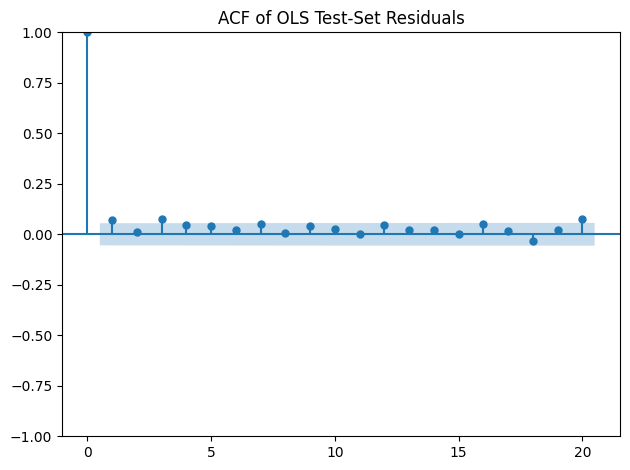

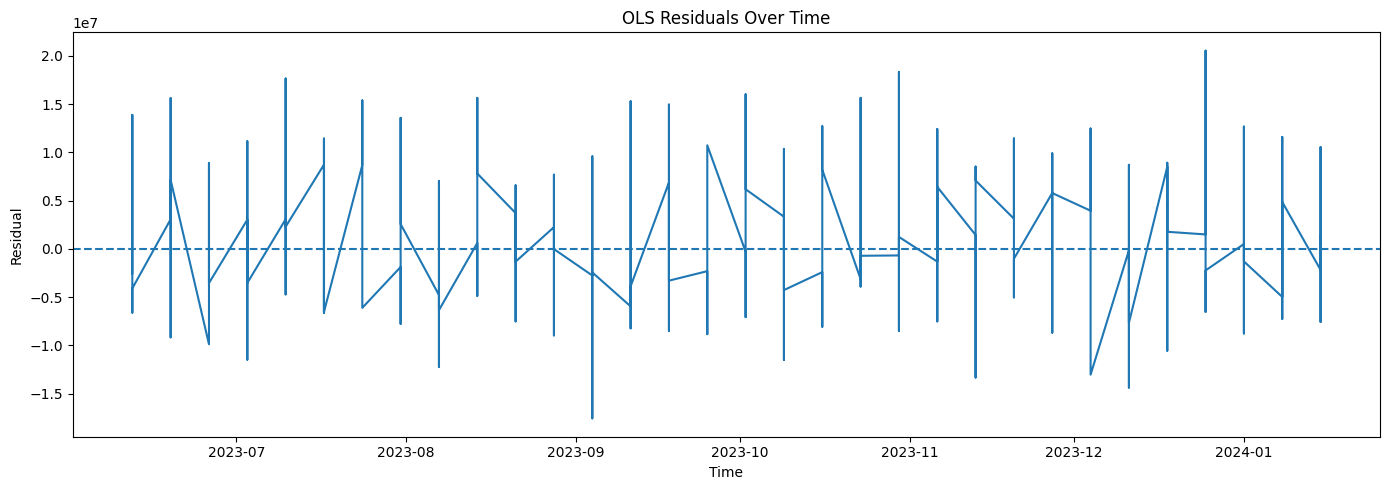

In [69]:
# ============================================================
# RESIDUAL TIME-DEPENDENCE DIAGNOSTICS
# ============================================================

from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Prepare residual data
# ------------------------------------------------------------

residual_df = test[
    ["time"]
].copy()

residual_df["OLS_residual"] = np.asarray(
    ols_residuals
)

residual_df["Ridge_residual"] = np.asarray(
    ridge_residuals
)

residual_df = residual_df.sort_values("time")


# ------------------------------------------------------------
# 2. Durbin-Watson test
# ------------------------------------------------------------

ols_dw = durbin_watson(
    residual_df["OLS_residual"]
)

ridge_dw = durbin_watson(
    residual_df["Ridge_residual"]
)

print("=" * 60)
print("DURBIN-WATSON TEST")
print("=" * 60)

print(f"OLS Durbin-Watson   : {ols_dw:.4f}")
print(f"Ridge Durbin-Watson : {ridge_dw:.4f}")


# ------------------------------------------------------------
# 3. Ljung-Box test
# ------------------------------------------------------------

print("\n")
print("=" * 60)
print("LJUNG-BOX TEST")
print("=" * 60)

ljung_box = acorr_ljungbox(
    residual_df["OLS_residual"],
    lags=[4, 8, 12],
    return_df=True
)

print(ljung_box)


# ------------------------------------------------------------
# 4. Residual ACF
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plot_acf(
    residual_df["OLS_residual"],
    lags=20,
    alpha=0.05
)

plt.title(
    "ACF of OLS Test-Set Residuals"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. Residuals over time
# ------------------------------------------------------------

plt.figure(figsize=(14, 5))

plt.plot(
    residual_df["time"],
    residual_df["OLS_residual"]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "OLS Residuals Over Time"
)

plt.xlabel("Time")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()

WEEKLY DURBIN-WATSON
OLS   : 1.3047
Ridge : 1.3048

WEEKLY LJUNG-BOX TEST — OLS
     lb_stat  lb_pvalue
4   4.633598   0.326999
8  14.215876   0.076309


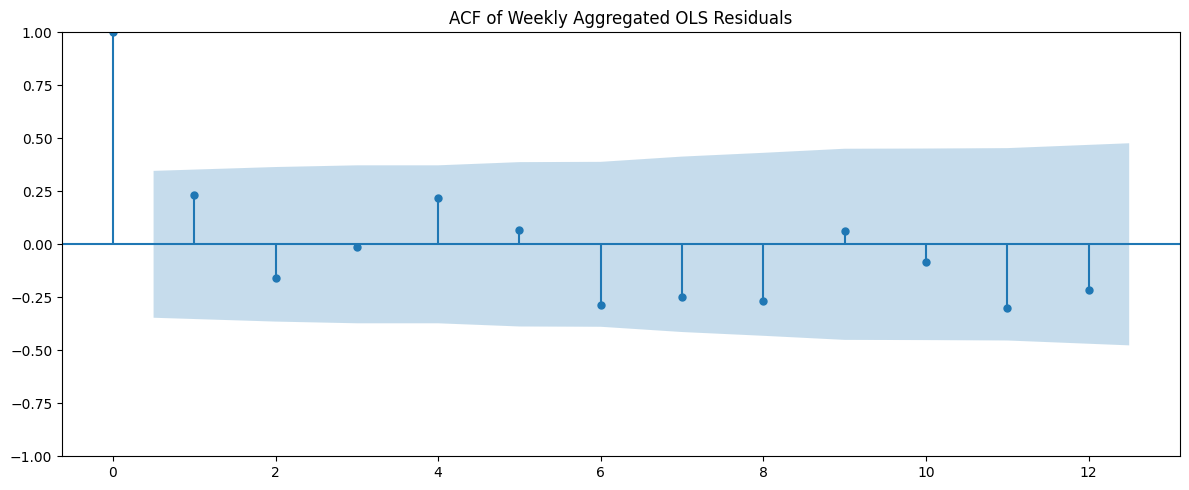

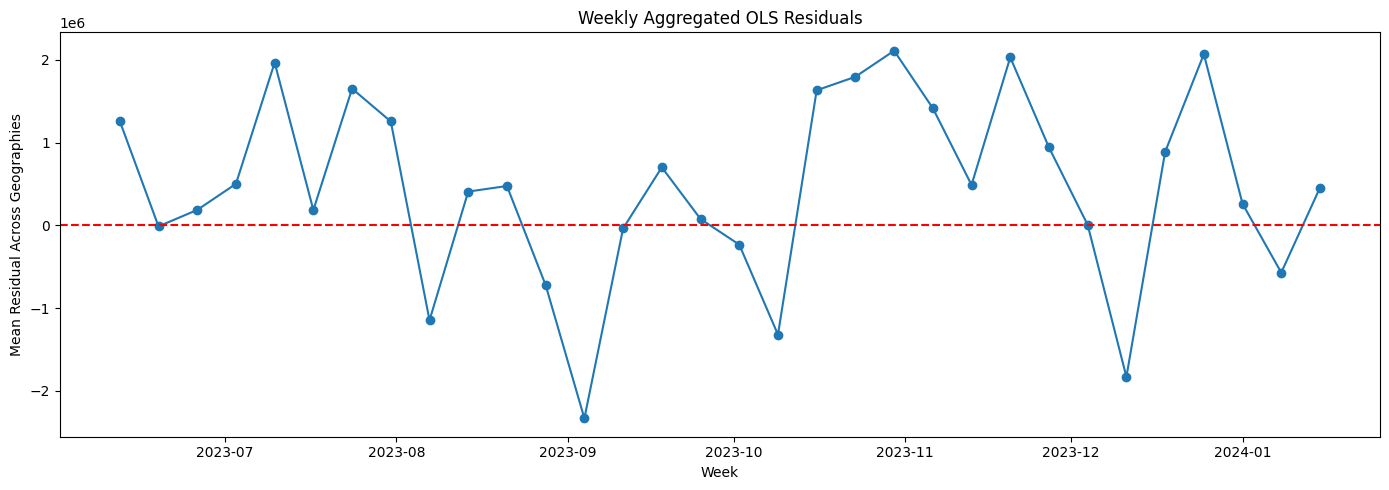

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox

# ------------------------------------------------------------
# 1. Create residual dataframe safely handling indexes
# ------------------------------------------------------------
test_df = test.reset_index()

residual_df = pd.DataFrame()
residual_df["geo"] = test_df["geo"] if "geo" in test_df.columns else test_df.iloc[:, 0]
residual_df["time"] = test_df["time"] if "time" in test_df.columns else test_df.iloc[:, 1]

residual_df["OLS_residual"] = np.asarray(ols_residuals)
residual_df["Ridge_residual"] = np.asarray(ridge_residuals)

# ------------------------------------------------------------
# 2. Aggregate mean residuals across geographies by week
# ------------------------------------------------------------
weekly_residuals = (
    residual_df
    .groupby("time", as_index=False)
    .agg({"OLS_residual": "mean", "Ridge_residual": "mean"})
    .sort_values("time")
)

# ------------------------------------------------------------
# 3. Diagnostic Tests & Plots
# ------------------------------------------------------------
print("WEEKLY DURBIN-WATSON")
print("=" * 60)
print(f"OLS   : {durbin_watson(weekly_residuals['OLS_residual']):.4f}")
print(f"Ridge : {durbin_watson(weekly_residuals['Ridge_residual']):.4f}")

print("\n" + "=" * 60)
print("WEEKLY LJUNG-BOX TEST — OLS")
print("=" * 60)
max_lag = min(12, len(weekly_residuals) // 4)
lags = [lag for lag in [4, 8, 12] if lag <= max_lag]
if lags:
    lb_test = acorr_ljungbox(weekly_residuals["OLS_residual"], lags=lags, return_df=True)
    print(lb_test)

# ACF Plot
fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(weekly_residuals["OLS_residual"], lags=min(12, len(weekly_residuals) // 2), alpha=0.05, ax=ax)
ax.set_title("ACF of Weekly Aggregated OLS Residuals")
plt.tight_layout()
plt.show()

# Residuals over time plot
plt.figure(figsize=(14, 5))
plt.plot(weekly_residuals["time"], weekly_residuals["OLS_residual"], marker="o")
plt.axhline(0, color="red", linestyle="--")
plt.title("Weekly Aggregated OLS Residuals")
plt.xlabel("Week")
plt.ylabel("Mean Residual Across Geographies")
plt.tight_layout()
plt.show()

In [75]:
# ============================================================
# REFINED ADSTOCK DECAY SEARCH
# Numerically stable version
# ============================================================

import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# ------------------------------------------------------------
# 1. Variables
# ------------------------------------------------------------

spend_cols = [
    "Channel0_spend",
    "Channel1_spend",
    "Channel2_spend",
    "Channel3_spend",
    "Channel4_spend"
]

control_cols = [
    "competitor_sales_control",
    "sentiment_score_control",
    "Promo"
]

target = "conversions"


# ------------------------------------------------------------
# 2. Stable geometric adstock
# ------------------------------------------------------------

def geometric_adstock(x, decay):

    x = np.asarray(x, dtype=float)

    result = np.zeros(len(x), dtype=float)

    if len(x) == 0:
        return result

    result[0] = x[0]

    for t in range(1, len(x)):
        result[t] = (
            x[t] +
            decay * result[t - 1]
        )

    return result


# ------------------------------------------------------------
# 3. Sort correctly within each geography
# ------------------------------------------------------------

adstock_df = (
    df_clean
    .sort_values(["geo", "time"])
    .reset_index(drop=True)
    .copy()
)


# ------------------------------------------------------------
# 4. Time-based train/test split
# ------------------------------------------------------------

unique_dates = (
    adstock_df["time"]
    .sort_values()
    .unique()
)

split_position = int(
    len(unique_dates) * 0.80
)

split_date = unique_dates[split_position]

train_dates = unique_dates[
    unique_dates < split_date
]

test_dates = unique_dates[
    unique_dates >= split_date
]


# ------------------------------------------------------------
# 5. Test finer decay grid
# ------------------------------------------------------------

decay_values = np.arange(
    0.00,
    0.91,
    0.05
)

results = []


# ------------------------------------------------------------
# 6. Evaluate each decay
# ------------------------------------------------------------

for decay in decay_values:

    temp = adstock_df[
        ["geo", "time", target] + control_cols
    ].copy()

    # -----------------------------------------------
    # Create adstock separately for every geography
    # -----------------------------------------------

    for col in spend_cols:

        temp[col + "_adstock"] = (
            adstock_df
            .groupby("geo", sort=False)[col]
            .transform(
                lambda x: pd.Series(
                    geometric_adstock(
                        x.values,
                        decay
                    ),
                    index=x.index
                )
            )
        )

    adstock_cols = [
        col + "_adstock"
        for col in spend_cols
    ]

    features = (
        adstock_cols +
        control_cols
    )

    # -----------------------------------------------
    # Train/test
    # -----------------------------------------------

    train = temp[
        temp["time"] < split_date
    ]

    test = temp[
        temp["time"] >= split_date
    ]

    X_train = train[features]
    y_train = train[target]

    X_test = test[features]
    y_test = test[target]

    # -----------------------------------------------
    # Scale predictors + target
    # -----------------------------------------------

    X_scaler = StandardScaler()

    y_scaler = StandardScaler()

    X_train_scaled = X_scaler.fit_transform(
        X_train
    )

    X_test_scaled = X_scaler.transform(
        X_test
    )

    y_train_scaled = y_scaler.fit_transform(
        y_train.values.reshape(-1, 1)
    ).ravel()

    # -----------------------------------------------
    # Ridge
    # -----------------------------------------------

    model = Ridge(
        alpha=1.0
    )

    model.fit(
        X_train_scaled,
        y_train_scaled
    )

    pred_scaled = model.predict(
        X_test_scaled
    )

    # Convert predictions back to original units

    predictions = y_scaler.inverse_transform(
        pred_scaled.reshape(-1, 1)
    ).ravel()

    # -----------------------------------------------
    # Metrics
    # -----------------------------------------------

    r2 = r2_score(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_test,
        predictions
    )

    results.append({
        "Decay": round(decay, 2),
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })


# ------------------------------------------------------------
# 7. Results
# ------------------------------------------------------------

adstock_results = pd.DataFrame(
    results
)

print("=" * 65)
print("REFINED ADSTOCK DECAY SEARCH")
print("=" * 65)

print(
    adstock_results.round(4).to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 8. Best decay
# ------------------------------------------------------------

best = (
    adstock_results
    .sort_values("RMSE")
    .iloc[0]
)

print("\n")
print("=" * 65)
print("BEST DECAY FROM REFINED SEARCH")
print("=" * 65)

print(
    f"Decay : {best['Decay']:.2f}"
)

print(
    f"R²    : {best['R2']:.4f}"
)

print(
    f"RMSE  : {best['RMSE']:,.2f}"
)

print(
    f"MAE   : {best['MAE']:,.2f}"
)


# ------------------------------------------------------------
# 9. Improvement relative to no adstock
# ------------------------------------------------------------

baseline = (
    adstock_results[
        adstock_results["Decay"] == 0.00
    ]
    .iloc[0]
)

rmse_improvement = (
    (baseline["RMSE"] - best["RMSE"])
    / baseline["RMSE"]
    * 100
)

mae_improvement = (
    (baseline["MAE"] - best["MAE"])
    / baseline["MAE"]
    * 100
)

print("\n")
print("=" * 65)
print("IMPROVEMENT FROM ADSTOCK")
print("=" * 65)

print(
    f"RMSE improvement : {rmse_improvement:.2f}%"
)

print(
    f"MAE improvement  : {mae_improvement:.2f}%"
)

/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/env

REFINED ADSTOCK DECAY SEARCH
 Decay     R2         RMSE          MAE
  0.00 0.4734 4537635.1702 3434457.0860
  0.05 0.4868 4479670.6396 3381884.6141
  0.10 0.4989 4426764.9469 3334049.0255
  0.15 0.5097 4378470.1684 3290902.5829
  0.20 0.5196 4334270.7298 3252758.7400
  0.25 0.5285 4293624.2979 3218020.4019
  0.30 0.5368 4255995.1660 3186624.8128
  0.35 0.5444 4220878.1167 3157940.6371
  0.40 0.5515 4187811.5114 3132101.0410
  0.45 0.5582 4156378.5481 3107490.6938
  0.50 0.5646 4126195.2991 3084149.5150
  0.55 0.5708 4096883.5091 3061177.7351
  0.60 0.5768 4068025.3946 3038135.5122
  0.65 0.5828 4039096.8071 3014498.4868
  0.70 0.5889 4009374.4190 2989172.5273
  0.75 0.5953 3977823.9783 2961176.3298
  0.80 0.6024 3943119.5566 2930492.3983
  0.85 0.6100 3905165.9368 2906688.0460
  0.90 0.6152 3879002.4086 2919519.6196


BEST DECAY FROM REFINED SEARCH
Decay : 0.90
R²    : 0.6152
RMSE  : 3,879,002.41
MAE   : 2,919,519.62


IMPROVEMENT FROM ADSTOCK
RMSE improvement : 14.51%
MAE improvement

/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/env

In [76]:
# ============================================================
# MARKETING MIX MODEL
# ADSTOCK + HILL SATURATION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# ------------------------------------------------------------
# 1. VARIABLES
# ------------------------------------------------------------

spend_cols = [
    "Channel0_spend",
    "Channel1_spend",
    "Channel2_spend",
    "Channel3_spend",
    "Channel4_spend"
]

control_cols = [
    "competitor_sales_control",
    "sentiment_score_control",
    "Promo"
]

target = "conversions"

ADSTOCK_DECAY = 0.90


# ------------------------------------------------------------
# 2. GEOMETRIC ADSTOCK
# ------------------------------------------------------------

def geometric_adstock(x, decay):

    x = np.asarray(x, dtype=float)

    result = np.zeros(len(x))

    if len(x) == 0:
        return result

    result[0] = x[0]

    for t in range(1, len(x)):
        result[t] = (
            x[t]
            + decay * result[t - 1]
        )

    return result


# ------------------------------------------------------------
# 3. HILL SATURATION
# ------------------------------------------------------------

def hill_saturation(x, alpha, k):

    x = np.asarray(x, dtype=float)

    # Avoid numerical problems
    x = np.maximum(x, 0)

    k = max(float(k), 1e-10)

    return (
        x ** alpha
    ) / (
        x ** alpha + k ** alpha
    )


# ------------------------------------------------------------
# 4. SORT DATA
# ------------------------------------------------------------

mmm_df = (
    df_clean
    .sort_values(["geo", "time"])
    .reset_index(drop=True)
    .copy()
)


# ------------------------------------------------------------
# 5. CREATE ADSTOCKED CHANNELS
# ------------------------------------------------------------

for col in spend_cols:

    adstock_col = col + "_adstock"

    mmm_df[adstock_col] = (
        mmm_df
        .groupby("geo", sort=False)[col]
        .transform(
            lambda x: pd.Series(
                geometric_adstock(
                    x.values,
                    ADSTOCK_DECAY
                ),
                index=x.index
            )
        )
    )


adstock_cols = [
    col + "_adstock"
    for col in spend_cols
]


# ------------------------------------------------------------
# 6. TIME-BASED TRAIN / TEST SPLIT
# ------------------------------------------------------------

unique_dates = (
    mmm_df["time"]
    .sort_values()
    .unique()
)

split_position = int(
    len(unique_dates) * 0.80
)

split_date = unique_dates[split_position]

train = mmm_df[
    mmm_df["time"] < split_date
].copy()

test = mmm_df[
    mmm_df["time"] >= split_date
].copy()


X_train_controls = train[control_cols]
X_test_controls = test[control_cols]

y_train = train[target]
y_test = test[target]


print("=" * 65)
print("ADSTOCK + SATURATION MODEL")
print("=" * 65)

print(
    "Adstock decay:",
    ADSTOCK_DECAY
)

print(
    "Training observations:",
    len(train)
)

print(
    "Testing observations:",
    len(test)
)


# ------------------------------------------------------------
# 7. BASELINE: LINEAR ADSTOCK
# ------------------------------------------------------------

X_train_linear = train[
    adstock_cols + control_cols
]

X_test_linear = test[
    adstock_cols + control_cols
]

# Standardize predictors
x_scaler = StandardScaler()

X_train_linear_scaled = (
    x_scaler.fit_transform(
        X_train_linear
    )
)

X_test_linear_scaled = (
    x_scaler.transform(
        X_test_linear
    )
)

# Standardize target
y_scaler = StandardScaler()

y_train_scaled = (
    y_scaler.fit_transform(
        y_train.values.reshape(-1, 1)
    ).ravel()
)

linear_model = Ridge(
    alpha=1.0
)

linear_model.fit(
    X_train_linear_scaled,
    y_train_scaled
)

linear_pred_scaled = linear_model.predict(
    X_test_linear_scaled
)

linear_pred = (
    y_scaler
    .inverse_transform(
        linear_pred_scaled.reshape(-1, 1)
    )
    .ravel()
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)


# ------------------------------------------------------------
# 8. HILL PARAMETER GRID
# ------------------------------------------------------------

# alpha controls the shape of the response curve
#
# alpha < 1  -> gradual saturation
# alpha = 1  -> standard Hill curve
# alpha > 1  -> more S-shaped response

alpha_values = [
    0.5,
    1.0,
    1.5,
    2.0,
    3.0
]


# k multiplier controls the half-saturation point.
#
# k = 0.5 × median -> earlier saturation
# k = 1.0 × median -> middle point
# k = 2.0 × median -> later saturation

k_multipliers = [
    0.5,
    1.0,
    2.0
]


saturation_results = []


# ------------------------------------------------------------
# 9. TEST HILL MODELS
# ------------------------------------------------------------

for alpha in alpha_values:

    for k_multiplier in k_multipliers:

        X_train_sat = pd.DataFrame(
            index=train.index
        )

        X_test_sat = pd.DataFrame(
            index=test.index
        )

        # --------------------------------------------
        # Transform each channel separately
        # --------------------------------------------

        for col in adstock_cols:

            # Training distribution determines k
            positive_values = (
                train.loc[
                    train[col] > 0,
                    col
                ]
            )

            # Robust fallback if a channel has
            # very few positive observations
            if len(positive_values) == 0:

                base_k = 1.0

            else:

                base_k = (
                    positive_values
                    .median()
                )

            k = (
                k_multiplier *
                base_k
            )

            transformed_col = (
                col + "_hill"
            )

            X_train_sat[
                transformed_col
            ] = hill_saturation(
                train[col].values,
                alpha,
                k
            )

            X_test_sat[
                transformed_col
            ] = hill_saturation(
                test[col].values,
                alpha,
                k
            )

        # --------------------------------------------
        # Add controls
        # --------------------------------------------

        for col in control_cols:

            X_train_sat[col] = (
                train[col].values
            )

            X_test_sat[col] = (
                test[col].values
            )

        # --------------------------------------------
        # Standardization
        # --------------------------------------------

        scaler = StandardScaler()

        X_train_scaled = (
            scaler.fit_transform(
                X_train_sat
            )
        )

        X_test_scaled = (
            scaler.transform(
                X_test_sat
            )
        )

        # --------------------------------------------
        # Ridge
        # --------------------------------------------

        model = Ridge(
            alpha=1.0
        )

        model.fit(
            X_train_scaled,
            y_train_scaled
        )

        pred_scaled = model.predict(
            X_test_scaled
        )

        predictions = (
            y_scaler
            .inverse_transform(
                pred_scaled.reshape(-1, 1)
            )
            .ravel()
        )

        # --------------------------------------------
        # Metrics
        # --------------------------------------------

        r2 = r2_score(
            y_test,
            predictions
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                predictions
            )
        )

        mae = mean_absolute_error(
            y_test,
            predictions
        )

        saturation_results.append({

            "Alpha": alpha,

            "K_multiplier": k_multiplier,

            "R2": r2,

            "RMSE": rmse,

            "MAE": mae
        })


# ------------------------------------------------------------
# 10. RESULTS
# ------------------------------------------------------------

saturation_results = pd.DataFrame(
    saturation_results
)

print("\n")
print("=" * 65)
print("LINEAR ADSTOCK BASELINE")
print("=" * 65)

print(
    f"R²   : {linear_r2:.4f}"
)

print(
    f"RMSE : {linear_rmse:,.2f}"
)

print(
    f"MAE  : {linear_mae:,.2f}"
)


print("\n")
print("=" * 65)
print("HILL SATURATION RESULTS")
print("=" * 65)

print(
    saturation_results
    .sort_values("RMSE")
    .round(4)
    .to_string(index=False)
)


# ------------------------------------------------------------
# 11. BEST HILL MODEL
# ------------------------------------------------------------

best_hill = (
    saturation_results
    .sort_values("RMSE")
    .iloc[0]
)

print("\n")
print("=" * 65)
print("BEST HILL SATURATION MODEL")
print("=" * 65)

print(
    f"Alpha       : {best_hill['Alpha']}"
)

print(
    f"K multiplier: {best_hill['K_multiplier']}"
)

print(
    f"R²          : {best_hill['R2']:.4f}"
)

print(
    f"RMSE        : {best_hill['RMSE']:,.2f}"
)

print(
    f"MAE         : {best_hill['MAE']:,.2f}"
)


# ------------------------------------------------------------
# 12. COMPARE LINEAR VS HILL
# ------------------------------------------------------------

rmse_improvement = (
    (linear_rmse - best_hill["RMSE"])
    / linear_rmse
    * 100
)

mae_improvement = (
    (linear_mae - best_hill["MAE"])
    / linear_mae
    * 100
)

r2_change = (
    best_hill["R2"]
    - linear_r2
)

print("\n")
print("=" * 65)
print("LINEAR ADSTOCK vs HILL SATURATION")
print("=" * 65)

print(
    f"Linear adstock R² : {linear_r2:.4f}"
)

print(
    f"Hill R²           : {best_hill['R2']:.4f}"
)

print(
    f"R² change         : {r2_change:+.4f}"
)

print(
    f"RMSE improvement  : {rmse_improvement:+.2f}%"
)

print(
    f"MAE improvement   : {mae_improvement:+.2f}%"
)

ADSTOCK + SATURATION MODEL
Adstock decay: 0.9
Training observations: 4960
Testing observations: 1280


LINEAR ADSTOCK BASELINE
R²   : 0.6152
RMSE : 3,879,002.41
MAE  : 2,919,519.62


HILL SATURATION RESULTS
 Alpha  K_multiplier     R2         RMSE          MAE
   2.0           2.0 0.6117 3896456.6345 2933237.9359
   1.5           2.0 0.6100 3904993.4905 2923862.5895
   1.0           2.0 0.5922 3993393.9526 2994930.1670
   3.0           2.0 0.5847 4029583.3811 3100432.0835
   2.0           1.0 0.5837 4034467.7314 3008817.7590
   3.0           1.0 0.5836 4035244.1834 3006910.9246
   1.5           1.0 0.5778 4063195.8741 3045946.8048
   1.0           1.0 0.5657 4121055.4738 3116455.8385
   0.5           2.0 0.5600 4147979.8312 3155955.2177
   0.5           1.0 0.5503 4193413.4270 3204410.9760
   0.5           0.5 0.5400 4241219.5863 3254252.7519
   1.0           0.5 0.5246 4311515.3768 3310482.3101
   1.5           0.5 0.5045 4401611.1663 3377995.9049
   2.0           0.5 0.4796 4510794.9

/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/tf_env/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/env